In [3]:
import networkx as nx
import osmnx as ox

# import matplotlib.animation as animation
ox.__version__

'1.8.0'

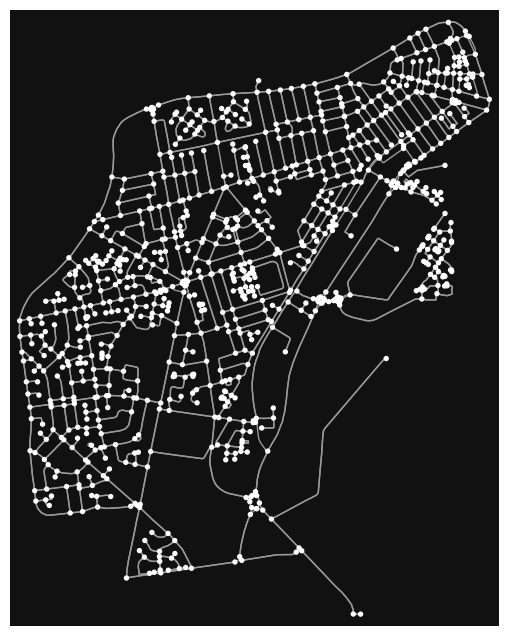

In [5]:
G = ox.graph_from_place("Fleetwood, England", network_type="drive")
fig, ax = ox.plot_graph(G)

In [50]:
import collection_deque_example as qsim
import time
from multiprocessing import Process
# import random
import numpy as np
# [a,b] = np.unique(EdgeList[0][0], return_index=True)
numRoads = len(G.nodes)
EdgeList = np.array(G.edges)
[from_u,from_uidx] = np.unique(EdgeList[:,0], return_index=True)
[to_u,to_uidx] = np.unique(EdgeList[:,1], return_index=True)


In [64]:


def runsim(simTime,numEntities,p,statusIterval,q):
    numServices = len(q)
    for _ in range(simTime):
            for i in range(numEntities):
                #e = PrioritizedItem(priority=1,item=simEntity('object'+str(i), sim_properties=p)) # to do
                e = qsim.simEntity('object_'+str(simTime)+"_"+str(i), sim_properties=p)
                q[-1].enqueue(e)
                
            else:
                for j in range(numServices):
                    q[j].process_items()

            if (_//statusIterval==_/statusIterval):
                print("Iteration" + str(_) + ". q len is now: "+str( len(q[-2]._queue) ))

if __name__ == '__main__':
    
    p = qsim.simProperites()
    numRoads = len(G.edges)
    print(numRoads)
    roads = []
 # stu fix this bit about road connecting 

    for i in range(numRoads):
        name = from_u[from_uidx == i]
        roads.append( qsim.Service(5, "terminus", "road " + str(name), capacity=2, resources=None) )
    for i in range(numRoads):
        destn = to_u[to_uidx == i]
        print(i)

        roads[i].next_q = roads[int(from_uidx[destn==from_u])]
    numEntities = 2 # per time step
    simTime = 24
    statusIterval = simTime // 4

    start = time.time()
    p = Process(target=runsim, args=(simTime,numEntities,p,statusIterval,roads))
    p.start()
    p.join()
    end = time.time()
    print("parallel sim took total of: ")
    print(end - start)

2279
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33


C:\Users\stuar\AppData\Local\Temp\ipykernel_13684\2615965659.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  roads[i].next_q = roads[int(from_uidx[destn==from_u])]


ValueError: operands could not be broadcast together with shapes (0,) (936,) 

In [118]:
# convert your MultiDiGraph to an undirected MultiGraph
M = ox.utils_graph.get_undirected(G)

# convert your MultiDiGraph to a DiGraph without parallel edges
D = ox.utils_graph.get_digraph(G)

In [120]:
# you can convert your graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_nodes.head()


,y,x,street_count,highway,geometry
osmid,,,,,
25608417,53.781904,-2.894256,3,NaN,POINT (-2.89426 53.78190)
25608418,53.782063,-2.894655,3,NaN,POINT (-2.89466 53.78206)
25608419,53.782326,-2.894466,3,NaN,POINT (-2.89447 53.78233)
25608420,53.782344,-2.894390,3,NaN,POINT (-2.89439 53.78234)
25608421,53.782249,-2.893972,3,NaN,POINT (-2.89397 53.78225)


In [ ]:
gdf_edges.head()

osmid  oneway lanes    ref            name  \
u        v          key                                                   
25608417 1147019017 0    176157945    True     1  B5259      Ribby Road   
         1147019358 0    319536982    True   NaN   A583             NaN   
25608418 25659502   0      4630209    True     2   A583  Blackpool Road   
         25608419   0    319536987    True   NaN   A583             NaN   
25608419 25608420   0    549312021    True   NaN   A583             NaN   

                           highway maxspeed reversed   length  \
u        v          key                                         
25608417 1147019017 0    secondary   50 mph    False   43.422   
         1147019358 0        trunk   50 mph    False   31.807   
25608418 25659502   0        trunk   50 mph    False  198.217   
         25608419   0        trunk   50 mph    False   34.271   
25608419 25608420   0        trunk   50 mph    False    5.343   

                                                                  geometry  \
u        v          key                                                      
25608417 1147019017 0    LINESTRING (-2.89426 53.78190, -2.89448 53.781...   
         1147019358 0    LINESTRING (-2.89426 53.78190, -2.89434 53.781...   
25608418 25659502   0    LINESTRING (-2.89466 53.78206, -2.89479 53.782...   
         25608419   0    LINESTRING (-2.89466 53.78206, -2.89467 53.782...   
25608419 25608420   0    LINESTRING (-2.89447 53.78233, -2.89439 53.78234)   

                           junction bridge  
u        v          key                     
25608417 1147019017 0           NaN    NaN  
         1147019358 0    roundabout    NaN  
25608418 25659502   0           NaN    NaN  
         25608419   0    roundabout    NaN  
25608419 25608420   0    roundabout    NaN

c:\Users\stuar\anaconda3\envs\ox\Lib\site-packages\osmnx\routing.py:49: UserWarning: The attribute 'travel_time' is missing or null on some edges.
  _verify_edge_attribute(G, weight)


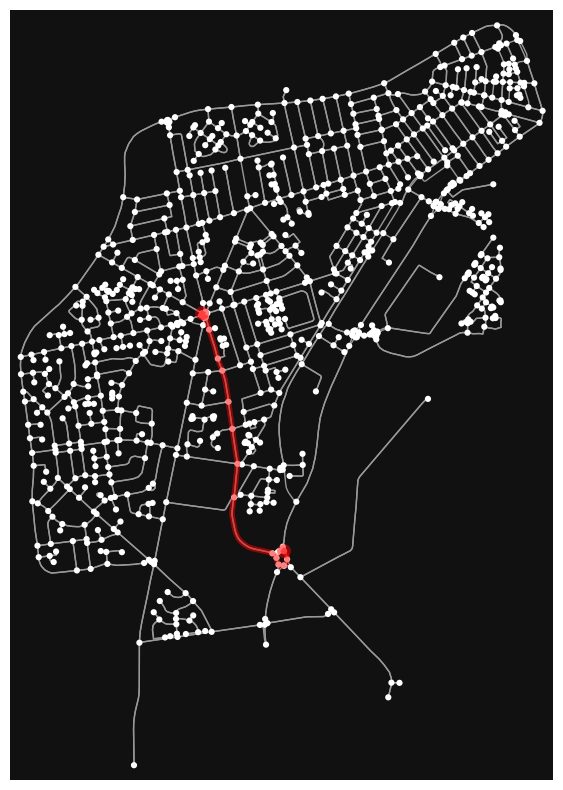

C:\Users\stuar\AppData\Local\Temp\ipykernel_13684\2409827939.py:24: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('foo.png'))


In [18]:
#generate GIF - random paths
import matplotlib.pyplot as plt
import imageio
images = []


G = ox.graph_from_place("Fleetwood, England", network_type="drive", truncate_by_edge=True)
L = list(G.nodes)
artists = []

for i in range(1):
    # G.remove_node(L[i])
    try:
        orig = ox.distance.nearest_nodes(G, X=gdf_nodes.iloc[i,[1]].values, Y=gdf_nodes.iloc[i,[0]].values)
        dest = ox.distance.nearest_nodes(G, X=gdf_nodes.iloc[i,[1]].values, Y=gdf_nodes.iloc[i,[0]].values)
    except:
        orig = L[i]
        dest = L[i+1]
    route = ox.shortest_path(G, orig, dest, weight="travel_time")
    fig, ax = ox.plot_graph_route(G, route, node_size=20,  figsize=(10, 10))
    
    fig.savefig('foo.png')

    images.append(imageio.imread('foo.png'))
    # imageio.mimsave('/tmp/fwoodsim.gif', images)


    
    


In [9]:
# what sized area does our network cover in square meters?
G_proj = ox.project_graph(G)
nodes_proj = ox.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.unary_union.convex_hull.area
graph_area_m

8306617.968710011

547


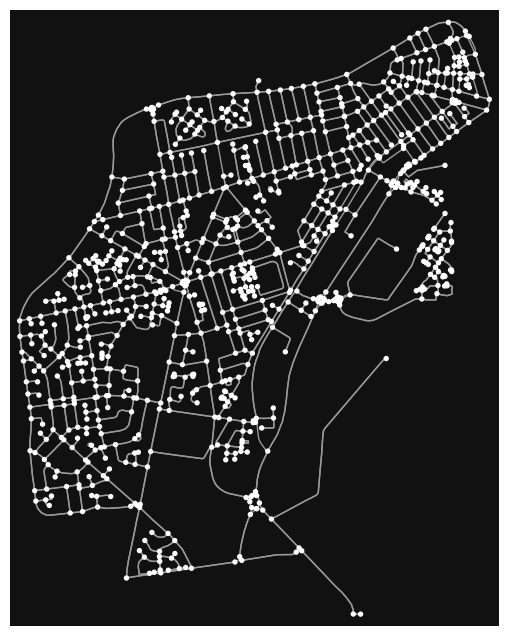

In [16]:
ints = ox.consolidate_intersections(G_proj, rebuild_graph=True, tolerance=15, dead_ends=False)
print(len(ints))
G = ox.graph_from_place("Fleetwood, England", network_type="drive")
fig, ax = ox.plot_graph(G)

In [12]:
# show some basic stats about the network
ox.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 936,
 'm': 2279,
 'k_avg': 4.869658119658119,
 'edge_length_total': 189340.486,
 'edge_length_avg': 83.08051162790697,
 'streets_per_node_avg': 2.6014957264957266,
 'streets_per_node_counts': {0: 0, 1: 225, 2: 0, 3: 635, 4: 75, 5: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.2403846153846154,
  2: 0.0,
  3: 0.6784188034188035,
  4: 0.08012820512820513,
  5: 0.0010683760683760685},
 'intersection_count': 711,
 'street_length_total': 97684.091,
 'street_segment_count': 1215,
 'street_length_avg': 80.39842880658436,
 'circuity_avg': 1.0395310304096341,
 'self_loop_proportion': 0.0016460905349794238,
 'clean_intersection_count': 547,
 'node_density_km': 112.68123844455044,
 'intersection_density_km': 85.59440227999505,
 'edge_density_km': 22793.932104885753,
 'street_density_km': 11759.790972446757,
 'clean_intersection_density_km': 65.8511083644969}

In [ ]:
# show some basic stats about the network
ox.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 420,
 'm': 889,
 'k_avg': 4.233333333333333,
 'edge_length_total': 72432.991,
 'edge_length_avg': 81.47693025871766,
 'streets_per_node_avg': 2.25,
 'streets_per_node_counts': {0: 0, 1: 163, 2: 0, 3: 246, 4: 11},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.3880952380952381,
  2: 0.0,
  3: 0.5857142857142857,
  4: 0.02619047619047619},
 'intersection_count': 257,
 'street_length_total': 37487.755,
 'street_segment_count': 468,
 'street_length_avg': 80.10204059829059,
 'circuity_avg': 1.0552374038904075,
 'self_loop_proportion': 0.0,
 'clean_intersection_count': 194,
 'node_density_km': 66.58380319334806,
 'intersection_density_km': 40.74294623973917,
 'edge_density_km': 11483.009565356073,
 'street_density_km': 5943.04119304869,
 'clean_intersection_density_km': 30.75537576073696}

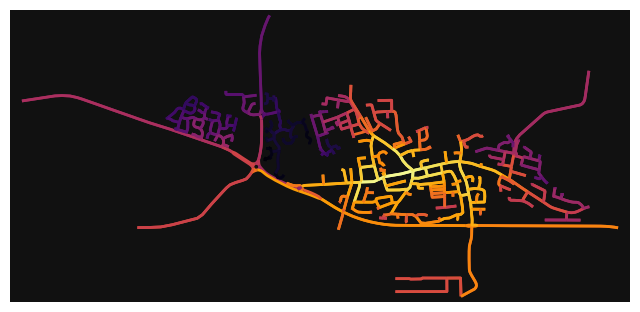

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

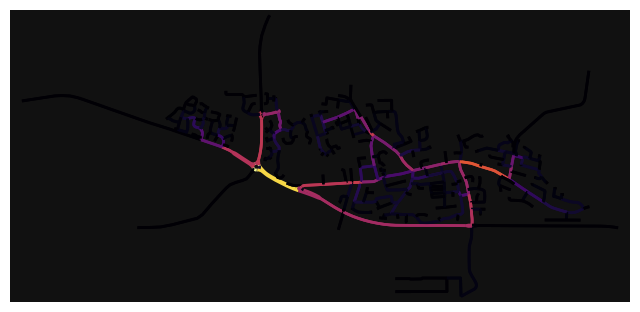

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.betweenness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)